# Comparative Gene Expression Analysis of Breast Tumor and Normal Samples (GSE25066 Dataset)

### Project Overview:

- ##### This project analyzes gene expression data to compare breast tumor and normal tissue samples using statistical methods and visualization techniques. The goal is to identify genes with significant expression differences and explore overall expression patterns between both conditions.


### Objectives
- ##### Compare gene expression profiles between tumor and normal samples
- ##### Identify significantly differentially expressed genes
- ##### Visualize gene-level differences using statistical and exploratory plots

### Tools and Technologies
- ##### Python (Pandas, NumPy, SciPy)
- ##### Data Visualization (Matplotlib, Seaborn)
- ##### Scikit-learn (PCA, StandardScaler)
- ##### Jupyter Notebook

### Project Workflow

- ##### Data collection, inspection, and preprocessing
- ##### Statistical analysis (correlation and differential expression testing)
- ##### Multiple testing correction (FDR adjustment)
- ##### Data visualization (bar plots, heatmaps, volcano plot, PCA)
- ##### Interpretation of statistical and visual results
- ##### Recommendations for further analysis
- ##### Final conclusions

### 1. Project Setup & Environment

In [1]:
# importing libraries for this projects
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.multitest import multipletests
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", context="notebook")

### 2. Data Loading

In [2]:
# Loading the tumor and normal gene expression datasets
tumor = pd.read_csv("GSE25066-Tumor.txt", sep = "\t", index_col=0)

normal = pd.read_csv("GSE25066-Normal.txt", sep = "\t", index_col=0)

### 3. Data Inspection

In [3]:
# Checking structure of datasets
print(f"Tumor Dataset Shape: {tumor.shape} (Rows, Columns)")
print(f"Missing Values: {tumor.isnull().sum().sum()}")
print(f"Duplicates: {tumor.duplicated().sum()}")
tumor.head()

Tumor Dataset Shape: (12634, 392) (Rows, Columns)
Missing Values: 0
Duplicates: 0


,patient-1,patient-2,patient-3,patient-5,patient-6,patient-7,patient-8,patient-9,patient-10,patient-11,...,patient-497,patient-498,patient-499,patient-500,patient-501,patient-503,patient-505,patient-506,patient-507,patient-508
Hybridization REF,,,,,,,,,,,,,,,,,,,,,
2,12.215645,13.988573,14.291476,12.785805,11.794836,16.192511,12.869975,13.249973,11.802740,11.958015,...,13.457213,9.648961,11.258780,12.775268,12.238787,11.475675,12.093756,12.505029,13.939546,12.959833
9,9.992839,12.905680,8.583623,9.499347,7.930721,7.752471,12.027260,8.694701,12.745403,9.133142,...,11.451496,13.158680,9.004336,9.879124,10.216237,12.497522,9.259501,11.730591,8.804734,8.882331
10,5.752235,4.527156,5.361369,5.031058,5.606644,5.759093,6.851911,6.349312,5.987554,7.067248,...,5.019484,6.695276,8.643460,6.792853,6.012154,6.197660,6.887878,5.611740,6.530070,6.381787
12,15.178096,13.730038,11.083116,11.970728,7.414998,12.939365,14.864565,15.066491,13.143580,9.998833,...,14.113289,11.285134,13.515185,10.755272,12.629051,13.376652,14.170173,14.245030,10.501130,11.685014
13,4.947088,4.643822,4.766606,6.363855,5.116873,6.282514,5.988840,5.538022,5.552420,6.986157,...,5.514218,5.822271,5.571440,7.016765,5.503115,5.737400,5.801156,5.480584,8.629061,6.323525


In [4]:
# Checking structure of datasets
print(f"Normal Dataset Shape: {normal.shape} (Rows, Columns)")
print(f"Missing Values: {normal.isnull().sum().sum()}")
print(f"Duplicates: {normal.duplicated().sum()}")
normal.head()

Normal Dataset Shape: (12634, 100) (Rows, Columns)
Missing Values: 0
Duplicates: 0


,patient-4,patient-15,patient-23,patient-27,patient-28,patient-42,patient-44,patient-45,patient-48,patient-51,...,patient-455,patient-459,patient-460,patient-462,patient-473,patient-478,patient-482,patient-483,patient-502,patient-504
Hybridization REF,,,,,,,,,,,,,,,,,,,,,
2,12.027604,13.900854,11.152164,12.421732,11.982737,14.030689,11.547195,13.395827,13.439608,14.030206,...,11.252449,10.911473,13.337793,13.910709,8.854670,9.842359,10.406411,9.697826,11.359760,13.248975
9,8.268311,8.227777,8.306369,14.775783,11.296656,8.517290,9.967458,8.513513,8.838466,10.066620,...,13.265206,11.022267,9.667603,9.411016,11.894196,8.337668,13.339416,9.346791,11.359525,8.670158
10,5.393059,5.733713,5.551158,5.819995,5.156046,6.771025,5.619529,7.271736,4.743302,5.278936,...,5.793354,8.826928,5.871209,6.847163,5.846197,6.337645,7.467352,6.328615,6.025891,6.513474
12,9.006283,12.137981,13.028404,14.086706,11.346116,12.023112,14.268290,15.446347,10.678241,14.516039,...,13.266540,12.116647,11.781314,11.717825,14.226362,10.586987,15.621731,8.129153,13.755478,13.411808
13,4.511244,6.785314,4.255196,4.295831,5.332657,4.896162,7.856896,5.642245,7.653373,4.659636,...,4.600496,7.202337,7.771792,5.749144,5.287751,5.151574,5.702702,5.273029,5.360985,8.444186


### 4. Data Preprocessing

In [5]:
#Added "tumor_" prefix to column names to easily differentiate tumor and normal samples during analysis.
tumor = tumor.rename(
    columns = lambda patient: 'tumor_' + str(patient)
)
tumor.head()

,tumor_patient-1,tumor_patient-2,tumor_patient-3,tumor_patient-5,tumor_patient-6,tumor_patient-7,tumor_patient-8,tumor_patient-9,tumor_patient-10,tumor_patient-11,...,tumor_patient-497,tumor_patient-498,tumor_patient-499,tumor_patient-500,tumor_patient-501,tumor_patient-503,tumor_patient-505,tumor_patient-506,tumor_patient-507,tumor_patient-508
Hybridization REF,,,,,,,,,,,,,,,,,,,,,
2,12.215645,13.988573,14.291476,12.785805,11.794836,16.192511,12.869975,13.249973,11.802740,11.958015,...,13.457213,9.648961,11.258780,12.775268,12.238787,11.475675,12.093756,12.505029,13.939546,12.959833
9,9.992839,12.905680,8.583623,9.499347,7.930721,7.752471,12.027260,8.694701,12.745403,9.133142,...,11.451496,13.158680,9.004336,9.879124,10.216237,12.497522,9.259501,11.730591,8.804734,8.882331
10,5.752235,4.527156,5.361369,5.031058,5.606644,5.759093,6.851911,6.349312,5.987554,7.067248,...,5.019484,6.695276,8.643460,6.792853,6.012154,6.197660,6.887878,5.611740,6.530070,6.381787
12,15.178096,13.730038,11.083116,11.970728,7.414998,12.939365,14.864565,15.066491,13.143580,9.998833,...,14.113289,11.285134,13.515185,10.755272,12.629051,13.376652,14.170173,14.245030,10.501130,11.685014
13,4.947088,4.643822,4.766606,6.363855,5.116873,6.282514,5.988840,5.538022,5.552420,6.986157,...,5.514218,5.822271,5.571440,7.016765,5.503115,5.737400,5.801156,5.480584,8.629061,6.323525


In [6]:
#Added "normal_" prefix to column names to easily differentiate tumor and normal samples during analysis.
normal = normal.rename(
    columns = lambda patient: 'normal_' + str(patient)
)
normal.head()

,normal_patient-4,normal_patient-15,normal_patient-23,normal_patient-27,normal_patient-28,normal_patient-42,normal_patient-44,normal_patient-45,normal_patient-48,normal_patient-51,...,normal_patient-455,normal_patient-459,normal_patient-460,normal_patient-462,normal_patient-473,normal_patient-478,normal_patient-482,normal_patient-483,normal_patient-502,normal_patient-504
Hybridization REF,,,,,,,,,,,,,,,,,,,,,
2,12.027604,13.900854,11.152164,12.421732,11.982737,14.030689,11.547195,13.395827,13.439608,14.030206,...,11.252449,10.911473,13.337793,13.910709,8.854670,9.842359,10.406411,9.697826,11.359760,13.248975
9,8.268311,8.227777,8.306369,14.775783,11.296656,8.517290,9.967458,8.513513,8.838466,10.066620,...,13.265206,11.022267,9.667603,9.411016,11.894196,8.337668,13.339416,9.346791,11.359525,8.670158
10,5.393059,5.733713,5.551158,5.819995,5.156046,6.771025,5.619529,7.271736,4.743302,5.278936,...,5.793354,8.826928,5.871209,6.847163,5.846197,6.337645,7.467352,6.328615,6.025891,6.513474
12,9.006283,12.137981,13.028404,14.086706,11.346116,12.023112,14.268290,15.446347,10.678241,14.516039,...,13.266540,12.116647,11.781314,11.717825,14.226362,10.586987,15.621731,8.129153,13.755478,13.411808
13,4.511244,6.785314,4.255196,4.295831,5.332657,4.896162,7.856896,5.642245,7.653373,4.659636,...,4.600496,7.202337,7.771792,5.749144,5.287751,5.151574,5.702702,5.273029,5.360985,8.444186


In [7]:
#Merged the two datasets for analysis
df = pd.concat([tumor, normal], axis = 1)

df.head()

,tumor_patient-1,tumor_patient-2,tumor_patient-3,tumor_patient-5,tumor_patient-6,tumor_patient-7,tumor_patient-8,tumor_patient-9,tumor_patient-10,tumor_patient-11,...,normal_patient-455,normal_patient-459,normal_patient-460,normal_patient-462,normal_patient-473,normal_patient-478,normal_patient-482,normal_patient-483,normal_patient-502,normal_patient-504
Hybridization REF,,,,,,,,,,,,,,,,,,,,,
2,12.215645,13.988573,14.291476,12.785805,11.794836,16.192511,12.869975,13.249973,11.802740,11.958015,...,11.252449,10.911473,13.337793,13.910709,8.854670,9.842359,10.406411,9.697826,11.359760,13.248975
9,9.992839,12.905680,8.583623,9.499347,7.930721,7.752471,12.027260,8.694701,12.745403,9.133142,...,13.265206,11.022267,9.667603,9.411016,11.894196,8.337668,13.339416,9.346791,11.359525,8.670158
10,5.752235,4.527156,5.361369,5.031058,5.606644,5.759093,6.851911,6.349312,5.987554,7.067248,...,5.793354,8.826928,5.871209,6.847163,5.846197,6.337645,7.467352,6.328615,6.025891,6.513474
12,15.178096,13.730038,11.083116,11.970728,7.414998,12.939365,14.864565,15.066491,13.143580,9.998833,...,13.266540,12.116647,11.781314,11.717825,14.226362,10.586987,15.621731,8.129153,13.755478,13.411808
13,4.947088,4.643822,4.766606,6.363855,5.116873,6.282514,5.988840,5.538022,5.552420,6.986157,...,4.600496,7.202337,7.771792,5.749144,5.287751,5.151574,5.702702,5.273029,5.360985,8.444186


In [8]:
# Checking merged dataset structure
print(f"Dataset Shape: {df.shape} (Rows, Columns)")
print(f"Missing Values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")
print(f"Summary Statistics:")
display(df.describe())

Dataset Shape: (12634, 492) (Rows, Columns)
Missing Values: 0
Duplicates: 0
Summary Statistics:


,tumor_patient-1,tumor_patient-2,tumor_patient-3,tumor_patient-5,tumor_patient-6,tumor_patient-7,tumor_patient-8,tumor_patient-9,tumor_patient-10,tumor_patient-11,...,normal_patient-455,normal_patient-459,normal_patient-460,normal_patient-462,normal_patient-473,normal_patient-478,normal_patient-482,normal_patient-483,normal_patient-502,normal_patient-504
count,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,...,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000,12634.000000
mean,8.063066,8.022040,8.058089,8.038684,7.977712,8.053724,8.021915,8.049791,8.008270,8.067905,...,8.079819,8.070787,8.125800,8.143276,8.014184,8.031279,8.024539,8.004334,8.069954,8.030545
std,2.172086,2.081332,2.089738,2.076712,2.137399,2.200073,2.053664,2.145855,2.075901,2.100638,...,2.058137,2.038656,2.027865,2.107723,2.044368,2.150956,2.039453,2.099886,2.052098,2.085441
min,0.371459,0.363719,0.429719,0.310069,-0.011363,-0.465057,0.980420,-1.435600,0.428173,0.295758,...,-0.630136,1.100689,0.714210,0.274023,0.189797,-0.171011,0.935496,0.941128,0.233410,-1.164311
25%,6.709614,6.741497,6.767234,6.749516,6.651075,6.691195,6.730270,6.686775,6.672351,6.753181,...,6.758953,6.775384,6.845269,6.872661,6.675111,6.669768,6.748276,6.671629,6.757548,6.720042
50%,8.215860,8.186836,8.161913,8.128326,8.059801,8.271926,8.139406,8.234541,8.105864,8.210754,...,8.162751,8.147848,8.190331,8.304098,8.093760,8.191438,8.104554,8.096510,8.137897,8.160402
75%,9.446532,9.358847,9.396143,9.348024,9.351017,9.491772,9.327536,9.437018,9.327673,9.407135,...,9.387544,9.373182,9.391048,9.436479,9.342568,9.424321,9.301416,9.348174,9.389017,9.348733
max,17.127661,17.182244,15.712050,16.773038,16.446824,16.330965,16.160157,17.604418,17.086825,16.194327,...,15.647195,15.520215,16.113209,17.045918,15.770900,16.816478,16.432511,15.473740,15.114045,16.614736


In [9]:
#checking the first & last 10 columns of the merged datasets
print(df.columns[:10])
print(df.columns[-10:])

Index(['tumor_patient-1', 'tumor_patient-2', 'tumor_patient-3',
       'tumor_patient-5', 'tumor_patient-6', 'tumor_patient-7',
       'tumor_patient-8', 'tumor_patient-9', 'tumor_patient-10',
       'tumor_patient-11'],
      dtype='object')
Index(['normal_patient-455', 'normal_patient-459', 'normal_patient-460',
       'normal_patient-462', 'normal_patient-473', 'normal_patient-478',
       'normal_patient-482', 'normal_patient-483', 'normal_patient-502',
       'normal_patient-504'],
      dtype='object')


### 5. Feature Separation

In [10]:
# Extracting tumor sample columns from the dataset and storing them in a list for further analysis.
tumor_cols = [col for col in df.columns if "tumor_" in col]
print(tumor_cols)

['tumor_patient-1', 'tumor_patient-2', 'tumor_patient-3', 'tumor_patient-5', 'tumor_patient-6', 'tumor_patient-7', 'tumor_patient-8', 'tumor_patient-9', 'tumor_patient-10', 'tumor_patient-11', 'tumor_patient-12', 'tumor_patient-13', 'tumor_patient-14', 'tumor_patient-16', 'tumor_patient-17', 'tumor_patient-18', 'tumor_patient-19', 'tumor_patient-20', 'tumor_patient-21', 'tumor_patient-22', 'tumor_patient-24', 'tumor_patient-25', 'tumor_patient-26', 'tumor_patient-29', 'tumor_patient-30', 'tumor_patient-31', 'tumor_patient-32', 'tumor_patient-33', 'tumor_patient-34', 'tumor_patient-35', 'tumor_patient-36', 'tumor_patient-37', 'tumor_patient-38', 'tumor_patient-39', 'tumor_patient-40', 'tumor_patient-41', 'tumor_patient-43', 'tumor_patient-46', 'tumor_patient-47', 'tumor_patient-49', 'tumor_patient-50', 'tumor_patient-52', 'tumor_patient-53', 'tumor_patient-54', 'tumor_patient-55', 'tumor_patient-56', 'tumor_patient-57', 'tumor_patient-58', 'tumor_patient-60', 'tumor_patient-61', 'tumor_

In [11]:
# Extracting normal sample columns from the dataset and storing them in a list for further analysis.
normal_cols = [col for col in df.columns if "normal_" in col]
print(normal_cols)

['normal_patient-4', 'normal_patient-15', 'normal_patient-23', 'normal_patient-27', 'normal_patient-28', 'normal_patient-42', 'normal_patient-44', 'normal_patient-45', 'normal_patient-48', 'normal_patient-51', 'normal_patient-59', 'normal_patient-69', 'normal_patient-72', 'normal_patient-76', 'normal_patient-80', 'normal_patient-86', 'normal_patient-91', 'normal_patient-96', 'normal_patient-98', 'normal_patient-99', 'normal_patient-106', 'normal_patient-107', 'normal_patient-114', 'normal_patient-116', 'normal_patient-117', 'normal_patient-118', 'normal_patient-120', 'normal_patient-145', 'normal_patient-147', 'normal_patient-161', 'normal_patient-168', 'normal_patient-169', 'normal_patient-175', 'normal_patient-185', 'normal_patient-189', 'normal_patient-196', 'normal_patient-198', 'normal_patient-205', 'normal_patient-212', 'normal_patient-215', 'normal_patient-229', 'normal_patient-230', 'normal_patient-236', 'normal_patient-239', 'normal_patient-241', 'normal_patient-243', 'normal_

### 6. Exploratory Statistical Analysis 

#### 6.1 Correlation Analysis

In [12]:
# Mean based Pearson correlation between tumor and normal expression
tumor_mean = df[tumor_cols].mean(axis=1)
normal_mean = df[normal_cols].mean(axis=1)

r_mean, p_mean = stats.pearsonr(tumor_mean, normal_mean)

print("=== Mean based Pearson Correlation ===")
print(f"r = {r_mean:.6f}")
print(f"p-value = {p_mean:.2e}\n")


# Median based Pearson correlation between tumor and normal expression
tumor_median = df[tumor_cols].median(axis=1)
normal_median = df[normal_cols].median(axis=1)

r_median, p_median = stats.pearsonr(tumor_median, normal_median)

print("=== Median based Pearson Correlation ===")
print(f"r = {r_median:.6f}")
print(f"p-value = {p_median:.2e}")

=== Mean based Pearson Correlation ===
r = 0.991714
p-value = 0.00e+00

=== Median based Pearson Correlation ===
r = 0.988997
p-value = 0.00e+00


##### Both mean (r = 0.992) and median (r = 0.989) based correlations show an extremely strong positive relationship between tumor and normal gene expression profiles.

### 7. Differential Expression Analysis

#### 7.1 Welch’s t-test

In [13]:
# Performing Welch’s t-test per gene
results = []

for hybridization_ref in df.index:
    normal_vals = df.loc[hybridization_ref, normal_cols]
    tumor_vals = df.loc[hybridization_ref, tumor_cols]

    t_stat, p_value = stats.ttest_ind(normal_vals, tumor_vals, equal_var=False)

    results.append([hybridization_ref, t_stat, p_value])

stats_df = pd.DataFrame(results, columns=["Hybridization REF", "t_stat", "p_value"]).set_index("Hybridization REF")

In [17]:
# Previewing the t-test results and p-values
stats_df.head()

,t_stat,p_value
Hybridization REF,,
2,-0.447681,6.550684e-01
9,-7.860784,2.654528e-13
10,-0.861107,3.902871e-01
12,-2.304492,2.250121e-02
13,1.108530,2.694157e-01


#### 7.2 Multiple Testing Correction (FDR)

In [18]:
# Correcting for multiple comparisons using FDR (Benjamini–Hochberg) to reduce false discovery rate
stats_df["adj_p"] = multipletests(stats_df["p_value"], method="fdr_bh")[1]

In [19]:
# Identifying genes with statistically meaningful expression differences after FDR correction
stats_df["significant"] = stats_df["adj_p"] < 0.05

In [20]:
# Displaying top genes ranked by statistical significance after FDR correction
stats_df.sort_values("adj_p").head()

,t_stat,p_value,adj_p,significant
Hybridization REF,,,,
7913,9.375853,6.104959e-17,7.713005e-13,True
890,8.770050,3.290469e-16,2.078589e-12,True
4781,8.898610,9.069835e-16,3.819610e-12,True
4175,8.798078,2.000555e-15,6.318753e-12,True
9833,8.658065,3.162593e-15,7.991240e-12,True


#### 7.3 Fold Change Calculation

In [21]:
# Computing mean expression per gene
stats_df["mean_tumor"] = df[tumor_cols].mean(axis=1)
stats_df["mean_normal"] = df[normal_cols].mean(axis=1)

In [22]:
# Calculating log2 fold change
stats_df["log2FC"] = np.log2(
    (stats_df["mean_tumor"] +1) / (stats_df["mean_normal"] +1)
)

In [23]:
# Previewing first 5 values
stats_df.head()

,t_stat,p_value,adj_p,significant,mean_tumor,mean_normal,log2FC
Hybridization REF,,,,,,,
2,-0.447681,6.550684e-01,8.074277e-01,False,11.299146,11.222468,0.009023
9,-7.860784,2.654528e-13,1.676866e-10,True,11.046310,9.465664,0.202927
10,-0.861107,3.902871e-01,5.986265e-01,False,6.247272,6.159480,0.017583
12,-2.304492,2.250121e-02,8.432385e-02,False,12.794239,12.299951,0.052645
13,1.108530,2.694157e-01,4.754572e-01,False,5.626903,5.768320,-0.030463


### 8. Data Visualization

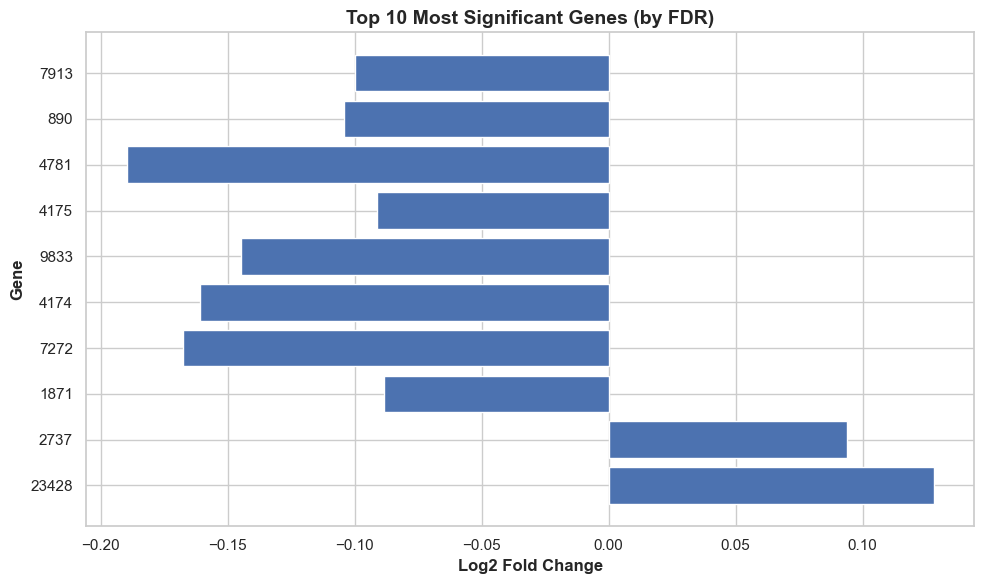

In [24]:
# Selecting top 10 most significant genes based on FDR-adjusted p-value
top_genes = stats_df.sort_values("adj_p").head(10)

fig, ax = plt.subplots(figsize=(10,6))

ax.barh(
    top_genes.index.astype(str),
    top_genes["log2FC"])

ax.set_title("Top 10 Most Significant Genes (by FDR)", fontsize=14, fontweight="bold")
ax.set_xlabel("Log2 Fold Change", fontweight="bold")
ax.set_ylabel("Gene", fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

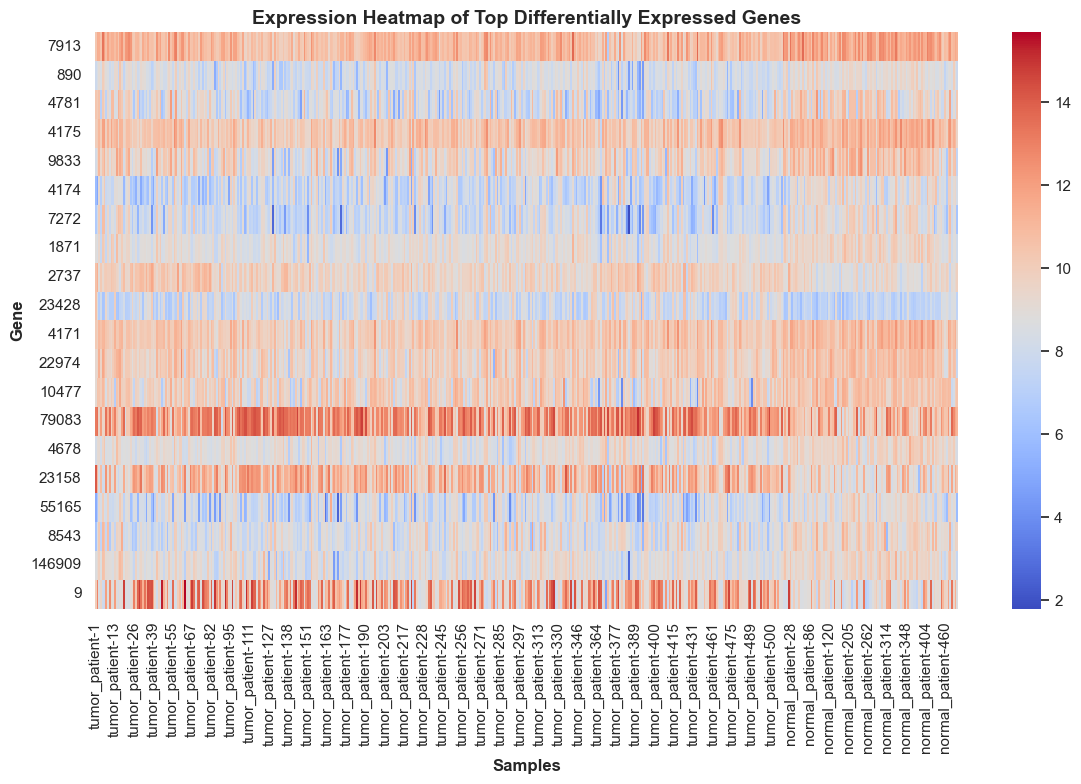

In [25]:
# Selecting top 20 most significant genes based on adjusted p-value
top_genes = stats_df.sort_values("adj_p").head(20)

# Extract expression values for top significant genes
heatmap_data = df.loc[top_genes.index]

fig, ax = plt.subplots(figsize=(12,8))

sns.heatmap(
    heatmap_data,
    cmap="coolwarm",
    ax=ax)

ax.set_title("Expression Heatmap of Top Differentially Expressed Genes", fontweight="bold", fontsize=14)
ax.set_xlabel("Samples", fontweight="bold")
ax.set_ylabel("Gene", fontweight="bold")
plt.tight_layout()
plt.savefig("expression_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

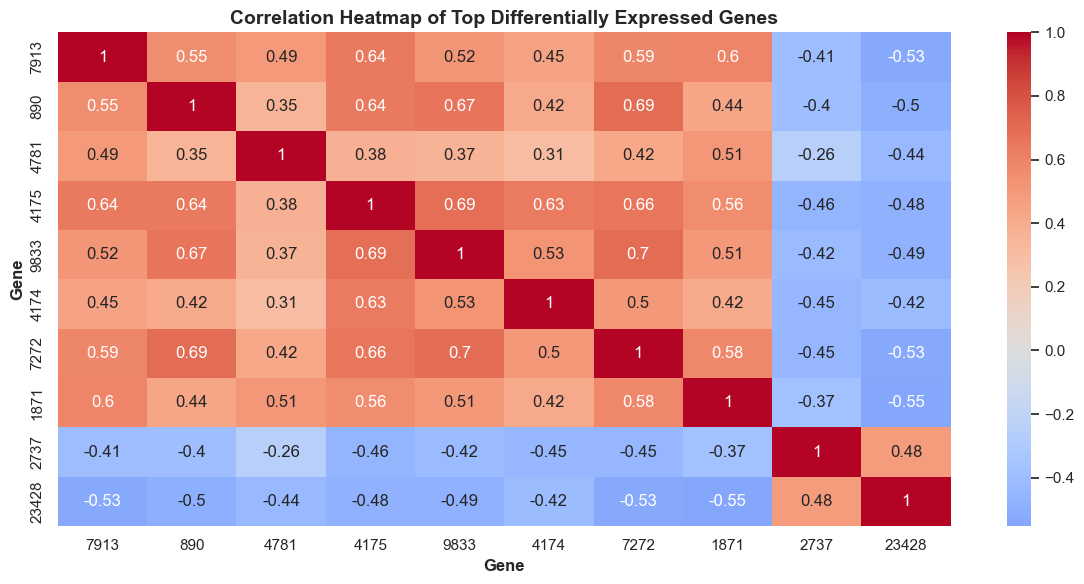

In [26]:
# Selecting top 10 most significant genes based on adjusted p-value
top_genes = stats_df.sort_values("adj_p").head(10)

corr_data = df.loc[top_genes.index].T.corr()

fig, ax = plt.subplots(figsize=(12,6))

sns.heatmap(corr_data, 
            cmap="coolwarm", 
            annot=True, 
            center=0,
            ax=ax)

ax.set_title("Correlation Heatmap of Top Differentially Expressed Genes", fontweight="bold", fontsize=14)
ax.set_xlabel("Gene", fontweight="bold")
ax.set_ylabel("Gene", fontweight="bold")
plt.tight_layout()
plt.show()

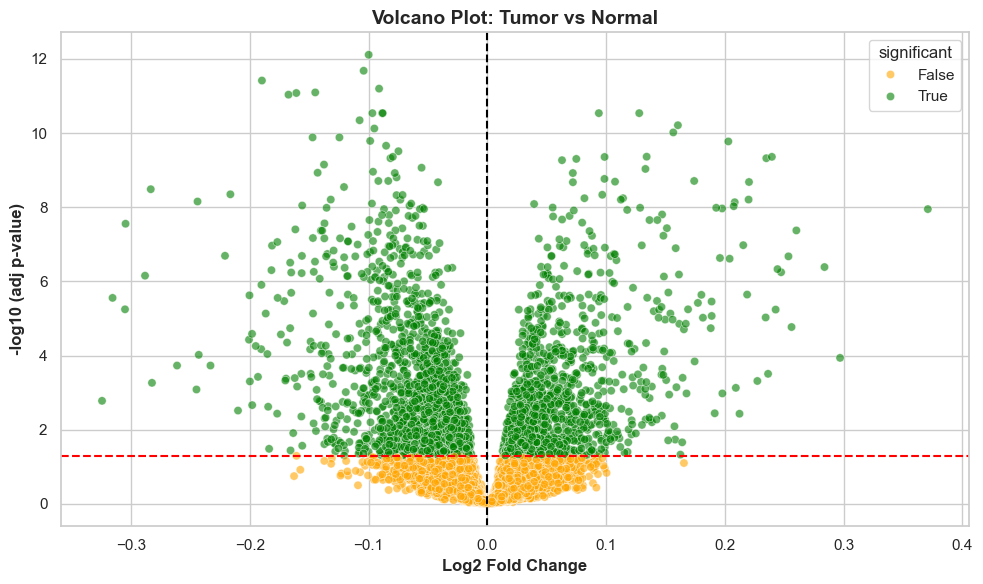

In [27]:
# Create -log10 of adjusted p-values and plotting volcano plots
stats_df["nega_log10_p"] = -np.log10(stats_df["adj_p"])

stats_df["significant"] = stats_df["adj_p"] < 0.05

fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=stats_df, 
                x="log2FC", 
                y="nega_log10_p",
                hue="significant", 
                palette={True: "green", False: "orange"}, 
                alpha=0.6,
                ax=ax)

ax.axhline(-np.log10(0.05), linestyle="--", color="red")
ax.axvline(0, linestyle="--", color="black")
ax.set_title("Volcano Plot: Tumor vs Normal", fontweight="bold", fontsize=14)
ax.set_xlabel("Log2 Fold Change", fontweight="bold")
ax.set_ylabel("-log10 (adj p-value)", fontweight="bold")
plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### 8.1 PCA (Dimensionality Reduction)

In [28]:
# Transposing the dataset so samples become rows and genes become columns
x = df.T

In [29]:
# Standardizing the gene expression values before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(x)

In [30]:
# Reducing the dataset into 2 principal components
pca = PCA(n_components=2)
pca_results = pca.fit_transform(X_scaled)

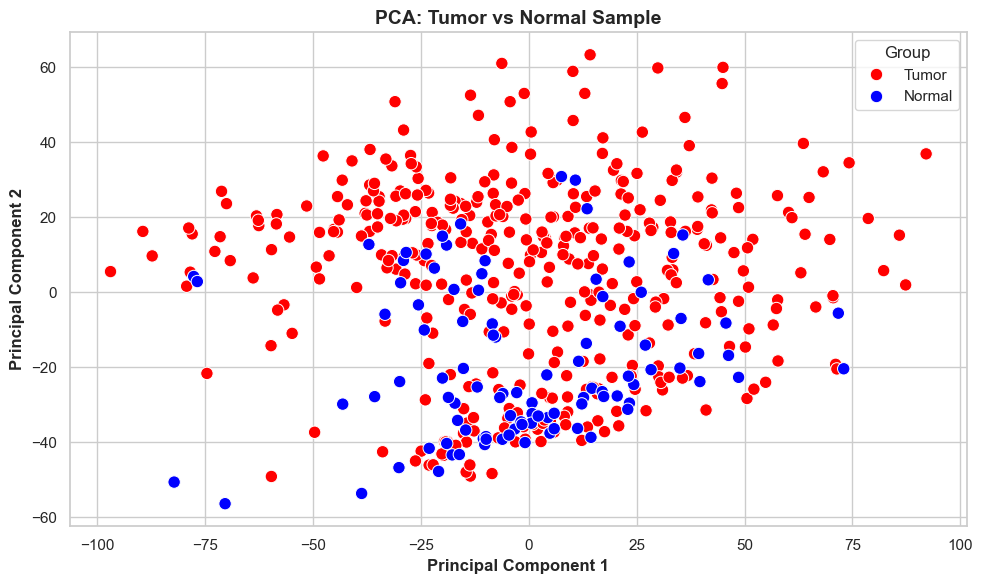

In [31]:
# Plotting PCA to visualize sample separation
labels = ["Normal" if "normal" in col else "Tumor" for col in x.index]

pca_df = pd.DataFrame(pca_results, columns=["PCA1", "PCA2"])
pca_df["Group"] = labels

fig, ax = plt.subplots(figsize=(10,6))

sns.scatterplot(data=pca_df,
                x="PCA1",
                y="PCA2",
                hue="Group",
                palette={"Tumor": "red", "Normal": "blue"},
                s=80,
                ax=ax)
ax.set_title("PCA: Tumor vs Normal Sample", fontweight="bold", fontsize=14)
ax.set_xlabel("Principal Component 1", fontweight="bold")
ax.set_ylabel("Principal Component 2", fontweight="bold")
plt.tight_layout()
plt.savefig("pca_plot.png", dpi=300, bbox_inches="tight")
plt.show()

### 9. Statistical Insights

**9.1 Global Expression Similarity (Correlation Analysis)**

A very high Pearson correlation (~0.99) was observed between tumor and normal gene expression profiles. This suggests that overall gene expression patterns are largely similar across both conditions, with only a subset of genes showing meaningful differences.

**9.2 Differential Gene Expression Analysis**

Differential expression analysis was performed using Welch’s t-test to compare gene expression levels between tumor and normal samples.

To reduce false positives from multiple testing, Benjamini–Hochberg False Discovery Rate (FDR) correction was applied.

### Key Observations:

* Several genes showed significant expression differences after FDR correction (adjusted p-value < 0.05).
* Some genes showed higher expression in tumor samples, while others showed lower expression compared to normal samples.
* Most genes did not show significant differences, suggesting that gene expression changes are concentrated in specific genes rather than affecting the entire genome.

### 10. Visual Insights

**10.1 Bar Chart (Top Differentially Expressed Genes)**

* The bar plot highlighted the genes with the strongest expression differences between tumor and normal samples.
* Genes with bars extending to the right showed higher expression in tumor samples, while genes extending to the left showed lower expression compared to normal tissues.
* Most of the top genes showed reduced expression in tumor samples, while a smaller number showed increased expression.
* The variation in bar lengths indicates differences in the magnitude of gene expression changes across the selected genes.
* Overall, the plot revealed noticeable differences in gene activity between tumor and normal samples, supporting the presence of differential expression patterns in the dataset.

**10.2 Expression Heatmap**

* The heatmap shows expression patterns of the top differentially expressed genes across all samples.
* Tumor and normal samples display distinct expression patterns, with clearer grouping within each condition.
* Tumor samples show more variation in expression intensity compared to normal samples, while normal samples appear more consistent across the selected genes.
* Overall, the heatmap suggests that the selected genes capture meaningful differences in expression patterns between tumor and normal groups.

**10.3 Correlation Heatmap**

* The correlation heatmap shows relationships between the top differentially expressed genes.
* Some genes show strong positive correlations, suggesting similar expression patterns across samples. Others show weaker or negative relationships, indicating differences in how their expression changes across conditions.
* Overall, the heatmap highlights variation in gene–gene relationships within the selected gene set.

**10.4 Volcano Plot (Fold Change vs Significance)**

* The volcano plot combines fold change and statistical significance to highlight genes with strong expression differences between tumor and normal samples.
* Genes located farther from the center and above the significance threshold represent those with both high fold change and strong statistical support.
* This plot helps to visually separate significantly differentially expressed genes from non-significant ones and is useful for prioritizing genes for further analysis.

**10.5 Principal Component Analysis (PCA)**

* PCA was used to reduce the high-dimensional gene expression data into two principal components for visualization.
* The plot shows partial separation between tumor and normal samples, suggesting differences in their overall gene expression patterns.
* Normal samples appear more tightly clustered, while tumor samples show greater spread across the principal component space.
* This indicates variation in how samples group based on global expression profiles.

### 11. Recommendations

Based on the findings from this analysis, the following recommendations are made:

**11.1 Prioritization of differentially expressed genes**

Focus on the top differentially expressed genes, as they are the most likely contributors to observed differences between tumor and normal samples and serve as primary candidates for further investigation.

**11.2 Functional and pathway analysis**

Perform Gene Ontology (GO) and KEGG pathway enrichment analysis to better understand the biological processes and pathways associated with the identified genes.

**11.3 Validation using independent datasets**

Validate the identified gene expression patterns using external datasets (e.g., GEO or TCGA) to ensure the results are consistent and not dataset-specific.

**11.4 Biomarker and classification exploration**

Further investigate whether the most differentially expressed genes can be used to distinguish between tumor and normal samples using basic classification or predictive modeling approaches.

**11.5 Gene network analysis**

Explore gene–gene interaction patterns using network or co-expression analysis to identify potential gene modules and relationships that may not be visible in individual gene analysis.

### 12. Conclusion

This study analyzed gene expression differences between tumor and normal samples using statistical testing and multiple visualization methods, including a bar chart, volcano plot, heatmap, correlation heatmap, and PCA.
The results show that while overall gene expression patterns are largely similar between both groups, a subset of genes exhibits significant differences. These genes account for most of the variation observed between tumor and normal samples.
Visual analyses support these findings, with clear separation patterns in PCA and distinct expression differences highlighted in the heatmap and volcano plot.
Overall, the analysis indicates that gene expression changes in tumor samples are selective, involving specific genes rather than widespread genomic alteration.